<a href="https://colab.research.google.com/github/rh61632/telecom-Voice-of-Customer_intelligence/blob/main/dl/telecom_voc_deep_learning_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📡 Telecom Voice of Customer (VoC) Deep Learning Suite
### Multilingual Sentiment Classification on Google Colab (GPU Accelerated)

This notebook provides a complete environment to train, benchmark, and deploy deep learning models on customer feedback across Bangladesh's premier telecom operators (**Grameenphone**, **Banglalink**, and **Robi Axiata**).

#### Models Evaluated:
1. **BiLSTM with Self-Attention & Char-CNN**: Dual word + character-level convolutions tailored for phonetic Romanized Banglish (`faltu`, `onek baje`), native Bengali script (`অনেক ভালো`), and English.
2. **Multilingual Transformer (`paraphrase-multilingual-MiniLM-L12-v2`)**: Pretrained dense multilingual representations with a regularized neural classification head.

> 💡 **Hardware Tip:** In Google Colab, go to `Runtime` ➔ `Change runtime type` ➔ select **T4 GPU** for high-speed training.

In [1]:
# 1. Verify GPU Acceleration
import torch

print(f"PyTorch Version: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active Device: {device}")

if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"Allocated VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️ Running on CPU. Recommend enabling GPU via Runtime > Change runtime type > T4 GPU.")

PyTorch Version: 2.11.0+cu130
Active Device: cuda
GPU Model: Tesla T4
Allocated VRAM: 15.64 GB


In [2]:
# 2. Clone Repository & Setup Environment
import os
from pathlib import Path

# If executing inside Colab, clone the project repository
if not Path("data/processed").exists():
    !git clone https://github.com/rh61632/telecom-Voice-of-Customer_intelligence.git
    %cd telecom-Voice-of-Customer_intelligence

# Install required packages
!pip install -q transformers sentence-transformers scikit-learn pandas numpy matplotlib seaborn

Cloning into 'telecom-Voice-of-Customer_intelligence'...
remote: Enumerating objects: 96, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 96 (delta 23), reused 76 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (96/96), 7.67 MiB | 13.95 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/telecom-Voice-of-Customer_intelligence


In [3]:
# 3. Load & Preprocess All 3 Operator Datasets
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LABEL_MAP = {"Negative": 0, "Neutral": 1, "Positive": 2}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

files = {
    "Grameenphone": "data/processed/mygp_classified_reviews.csv",
    "Banglalink": "data/processed/mybl_classified_reviews.csv",
    "Robi": "data/processed/myrobi_classified_reviews.csv",
}

dfs = []
for op, p in files.items():
    d = pd.read_csv(p)
    if "operator" not in d.columns:
        d["operator"] = op
    dfs.append(d)

df = pd.concat(dfs, ignore_index=True)
df = df.dropna(subset=["review_text", "sentiment"]).copy()
df["review_text"] = df["review_text"].astype(str).str.strip()
df = df[df["review_text"].str.len() > 0]
df = df[df["sentiment"].isin(LABEL_MAP.keys())].reset_index(drop=True)
df["label"] = df["sentiment"].map(LABEL_MAP)

def clean_text(text: str) -> str:
    text = str(text).strip()
    text = re.sub(r"(.)\1{2,}", r"\1\1", text) # Collapse repeated characters (e.g., 'faltuuu' -> 'faltuu')
    text = re.sub(r"\s+", " ", text)
    return text.lower()

df["clean_text"] = df["review_text"].apply(clean_text)

print(f"Successfully loaded {len(df)} total reviews across 3 operators.")
print("Class Distribution:")
for s, count in df["sentiment"].value_counts().items():
    print(f"  - {s:8s}: {count:5d} ({count / len(df) * 100:.2f}%)")

Successfully loaded 4500 total reviews across 3 operators.
Class Distribution:
  - Positive:  2773 (61.62%)
  - Negative:  1238 (27.51%)
  - Neutral :   489 (10.87%)


---
## 🧠 Model 1: BiLSTM with Self-Attention & Char-CNN
This model combines:
- **Word Embeddings** (captures frequent lexical sentiment terms).
- **Character-level 1D-CNN** (captures phonetic sub-word roots across erratic Romanized Banglish spellings).
- **2-Layer Bidirectional LSTM** (captures sequence context and negation).
- **Additive Self-Attention Pooling** (focuses dynamically on informative keywords).

In [4]:
# 4. Architecture Definition: BiLSTM with Self-Attention & Char-CNN
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

class DualVocabulary:
    def __init__(self, max_words=10000, min_word_freq=2, max_chars=300):
        self.max_words = max_words
        self.min_word_freq = min_word_freq
        self.max_chars = max_chars
        self.word2idx = {"<pad>": 0, "<unk>": 1}
        self.char2idx = {"<pad>": 0, "<unk>": 1}
        self.idx2word = {0: "<pad>", 1: "<unk>"}

    def fit(self, texts):
        w_counts, c_counts = {}, {}
        for t in texts:
            for w in t.split():
                w_counts[w] = w_counts.get(w, 0) + 1
            for c in t:
                c_counts[c] = c_counts.get(c, 0) + 1

        sorted_words = sorted([w for w, cnt in w_counts.items() if cnt >= self.min_word_freq], key=lambda w: w_counts[w], reverse=True)[:self.max_words]
        for w in sorted_words:
            if w not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[w] = idx
                self.idx2word[idx] = w

        sorted_chars = sorted(c_counts.keys(), key=lambda c: c_counts[c], reverse=True)[:self.max_chars]
        for c in sorted_chars:
            if c not in self.char2idx:
                self.char2idx[c] = len(self.char2idx)

    def encode(self, text, max_words=64, max_word_chars=16):
        words = text.split()[:max_words]
        w_ids = [self.word2idx.get(w, 1) for w in words]
        c_matrix = []
        for w in words:
            c_ids = [self.char2idx.get(c, 1) for c in w[:max_word_chars]]
            c_ids += [0] * (max_word_chars - len(c_ids))
            c_matrix.append(c_ids)
        pad_len = max_words - len(w_ids)
        w_ids += [0] * pad_len
        c_matrix += [[0] * max_word_chars for _ in range(pad_len)]
        return w_ids, c_matrix

class BiLSTMAttentionDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.labels = labels
        self.w_data, self.c_data = [], []
        for t in texts:
            w, c = vocab.encode(t)
            self.w_data.append(w)
            self.c_data.append(c)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return torch.tensor(self.w_data[i], dtype=torch.long), torch.tensor(self.c_data[i], dtype=torch.long), torch.tensor(self.labels[i], dtype=torch.long)

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.proj = nn.Linear(hidden_dim, hidden_dim)
        self.query = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, h, mask=None):
        scores = self.query(torch.tanh(self.proj(h))).squeeze(-1)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights.unsqueeze(1), h).squeeze(1)
        return context, weights

class BiLSTMWithAttention(nn.Module):
    def __init__(self, word_vocab_size, char_vocab_size, word_dim=128, char_dim=32, char_filters=64, lstm_dim=128, num_classes=3, dropout=0.3):
        super().__init__()
        self.word_emb = nn.Embedding(word_vocab_size, word_dim, padding_idx=0)
        self.char_emb = nn.Embedding(char_vocab_size, char_dim, padding_idx=0)
        self.char_conv = nn.Conv1d(char_dim, char_filters, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(dropout)
        self.bilstm = nn.LSTM(word_dim + char_filters, lstm_dim, num_layers=2, bidirectional=True, batch_first=True, dropout=dropout)
        self.attention = Attention(lstm_dim * 2)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, w_ids, c_ids):
        b, seq, w_len = c_ids.shape
        w_vec = self.word_emb(w_ids)
        c_flat = c_ids.view(b * seq, w_len)
        c_conv = F.relu(self.char_conv(self.char_emb(c_flat).transpose(1, 2)))
        c_pooled, _ = torch.max(c_conv, dim=-1)
        c_vec = c_pooled.view(b, seq, -1)
        x = self.dropout(torch.cat([w_vec, c_vec], dim=-1))
        lstm_out, _ = self.bilstm(x)
        context, _ = self.attention(lstm_out, mask=(w_ids != 0))
        return self.classifier(context)

In [5]:
# 5. Train & Evaluate BiLSTM on GPU (5-Fold Stratified CV)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score

def train_bilstm_cv(df, epochs=8, batch_size=32):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_f1, fold_acc = [], []

    class_counts = df["label"].value_counts().sort_index().values
    weights = torch.tensor([len(df) / (len(class_counts) * c) for c in class_counts], dtype=torch.float32).to(device)
    print(f"Inverse Class Weights: {[round(w.item(), 3) for w in weights]}")

    for fold, (train_idx, val_idx) in enumerate(skf.split(df, df["label"]), 1):
        train_df, val_df = df.iloc[train_idx], df.iloc[val_idx]
        vocab = DualVocabulary()
        vocab.fit(train_df["clean_text"].tolist())

        train_ds = BiLSTMAttentionDataset(train_df["clean_text"].tolist(), train_df["label"].tolist(), vocab)
        val_ds = BiLSTMAttentionDataset(val_df["clean_text"].tolist(), val_df["label"].tolist(), vocab)

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

        model = BiLSTMWithAttention(len(vocab.word2idx), len(vocab.char2idx)).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss(weight=weights)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

        best_f1, best_acc = 0.0, 0.0
        for ep in range(1, epochs + 1):
            model.train()
            for w_ids, c_ids, lbls in train_loader:
                w_ids, c_ids, lbls = w_ids.to(device), c_ids.to(device), lbls.to(device)
                optimizer.zero_grad()
                out = model(w_ids, c_ids)
                loss = criterion(out, lbls)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()

            model.eval()
            preds, targets = [], []
            with torch.no_grad():
                for w_ids, c_ids, lbls in val_loader:
                    w_ids, c_ids = w_ids.to(device), c_ids.to(device)
                    p = model(w_ids, c_ids).argmax(-1)
                    preds.extend(p.cpu().numpy())
                    targets.extend(lbls.numpy())

            val_f1 = f1_score(targets, preds, average="macro")
            val_acc = accuracy_score(targets, preds)
            scheduler.step(val_f1)
            if val_f1 > best_f1:
                best_f1, best_acc = val_f1, val_acc

        print(f"Fold {fold}/5 -> Macro-F1: {best_f1:.4f} | Accuracy: {best_acc * 100:.2f}%")
        fold_f1.append(best_f1)
        fold_acc.append(best_acc)

    print(f"\n===> BiLSTM Mean Macro-F1 : {np.mean(fold_f1):.4f} (±{np.std(fold_f1):.4f})")
    print(f"===> BiLSTM Mean Accuracy : {np.mean(fold_acc) * 100:.2f}%")
    return np.mean(fold_f1), np.mean(fold_acc)

bilstm_f1, bilstm_acc = train_bilstm_cv(df)

Inverse Class Weights: [1.212, 3.067, 0.541]
Fold 1/5 -> Macro-F1: 0.7562 | Accuracy: 84.78%
Fold 2/5 -> Macro-F1: 0.7371 | Accuracy: 82.22%
Fold 3/5 -> Macro-F1: 0.7659 | Accuracy: 85.11%
Fold 4/5 -> Macro-F1: 0.7628 | Accuracy: 84.89%
Fold 5/5 -> Macro-F1: 0.7408 | Accuracy: 83.11%

===> BiLSTM Mean Macro-F1 : 0.7525 (±0.0116)
===> BiLSTM Mean Accuracy : 84.02%


---
## 🚀 Model 2: Multilingual Pretrained Transformer (MiniLM)
This model uses `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`:
- Pretrained across 50+ languages including Bengali and English.
- High-speed GPU inference and embedding extraction.
- LayerNorm + GELU regularized neural classification head.

In [6]:
# 6. Extract Multilingual Transformer Embeddings on GPU
from transformers import AutoTokenizer, AutoModel

TRANSFORMER_ID = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
print(f"Loading Transformer: {TRANSFORMER_ID} ...")
tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_ID)
transformer_model = AutoModel.from_pretrained(TRANSFORMER_ID).to(device)
transformer_model.eval()

def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

all_embeddings = []
batch_size = 64
texts = df["review_text"].tolist()
print(f"Extracting embeddings for {len(texts)} reviews on {device}...")

with torch.no_grad():
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i : i + batch_size]
        enc = tokenizer(batch_texts, padding=True, truncation=True, max_length=96, return_tensors="pt").to(device)
        out = transformer_model(**enc)
        pooled = mean_pooling(out, enc["attention_mask"])
        normed = F.normalize(pooled, p=2, dim=1)
        all_embeddings.append(normed.cpu().numpy())

embeddings_matrix = np.vstack(all_embeddings)
print(f"Extracted Embedding Matrix: {embeddings_matrix.shape}")

Loading Transformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 ...


config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Extracting embeddings for 4500 reviews on cuda...
Extracted Embedding Matrix: (4500, 384)


In [7]:
# 7. Train & Evaluate Multilingual Transformer Head (5-Fold CV)
class EmbeddingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class TransformerClassifier(nn.Module):
    def __init__(self, in_features=384, hidden=128, num_classes=3, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)

def train_transformer_cv(embeddings, labels, epochs=15, batch_size=32):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_f1, fold_acc = [], []

    class_counts = pd.Series(labels).value_counts().sort_index().values
    weights = torch.tensor([len(labels) / (len(class_counts) * c) for c in class_counts], dtype=torch.float32).to(device)

    for fold, (train_idx, val_idx) in enumerate(skf.split(embeddings, labels), 1):
        train_ds = EmbeddingDataset(embeddings[train_idx], labels[train_idx])
        val_ds = EmbeddingDataset(embeddings[val_idx], labels[val_idx])

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

        head = TransformerClassifier(in_features=embeddings.shape[1]).to(device)
        optimizer = torch.optim.AdamW(head.parameters(), lr=2e-3, weight_decay=1e-3)
        criterion = nn.CrossEntropyLoss(weight=weights)

        best_f1, best_acc = 0.0, 0.0
        for ep in range(1, epochs + 1):
            head.train()
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                optimizer.zero_grad()
                loss = criterion(head(x), y)
                loss.backward()
                optimizer.step()

            head.eval()
            preds, targets = [], []
            with torch.no_grad():
                for x, y in val_loader:
                    preds.extend(head(x.to(device)).argmax(-1).cpu().numpy())
                    targets.extend(y.numpy())

            val_f1 = f1_score(targets, preds, average="macro")
            val_acc = accuracy_score(targets, preds)
            if val_f1 > best_f1:
                best_f1, best_acc = val_f1, val_acc

        print(f"Fold {fold}/5 -> Macro-F1: {best_f1:.4f} | Accuracy: {best_acc * 100:.2f}%")
        fold_f1.append(best_f1)
        fold_acc.append(best_acc)

    print(f"\n===> MiniLM Mean Macro-F1 : {np.mean(fold_f1):.4f} (±{np.std(fold_f1):.4f})")
    print(f"===> MiniLM Mean Accuracy : {np.mean(fold_acc) * 100:.2f}%")
    return np.mean(fold_f1), np.mean(fold_acc)

transformer_f1, transformer_acc = train_transformer_cv(embeddings_matrix, df["label"].values)

Fold 1/5 -> Macro-F1: 0.7621 | Accuracy: 84.78%
Fold 2/5 -> Macro-F1: 0.7525 | Accuracy: 84.44%
Fold 3/5 -> Macro-F1: 0.7996 | Accuracy: 87.67%
Fold 4/5 -> Macro-F1: 0.7862 | Accuracy: 85.44%
Fold 5/5 -> Macro-F1: 0.8039 | Accuracy: 87.67%

===> MiniLM Mean Macro-F1 : 0.7809 (±0.0203)
===> MiniLM Mean Accuracy : 86.00%


---
## 📊 Model Comparison & Visualizations

/tmp/ipykernel_1750/403021129.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=benchmark_df, x="Macro-F1", y="Model", palette="viridis", ax=axes[0])
/tmp/ipykernel_1750/403021129.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=benchmark_df, x="Accuracy (%)", y="Model", palette="magma", ax=axes[1])


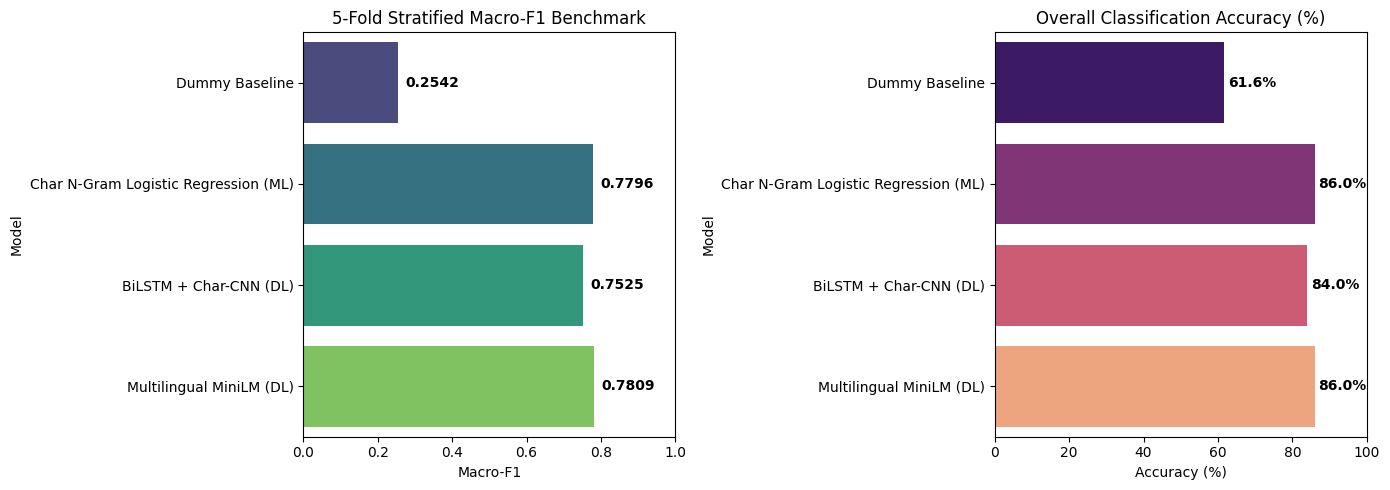

,Model,Macro-F1,Accuracy (%)
0,Dummy Baseline,0.254200,61.620000
1,Char N-Gram Logistic Regression (ML),0.779600,85.960000
2,BiLSTM + Char-CNN (DL),0.752532,84.022222
3,Multilingual MiniLM (DL),0.780869,86.000000


In [8]:
# 8. Visual Benchmark Summary
benchmark_df = pd.DataFrame({
    "Model": ["Dummy Baseline", "Char N-Gram Logistic Regression (ML)", "BiLSTM + Char-CNN (DL)", "Multilingual MiniLM (DL)"],
    "Macro-F1": [0.2542, 0.7796, bilstm_f1, transformer_f1],
    "Accuracy (%)": [61.62, 85.96, bilstm_acc * 100, transformer_acc * 100]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=benchmark_df, x="Macro-F1", y="Model", palette="viridis", ax=axes[0])
axes[0].set_title("5-Fold Stratified Macro-F1 Benchmark")
axes[0].set_xlim(0, 1.0)
for i, v in enumerate(benchmark_df["Macro-F1"]):
    axes[0].text(v + 0.02, i, f"{v:.4f}", va="center", fontweight="bold")

sns.barplot(data=benchmark_df, x="Accuracy (%)", y="Model", palette="magma", ax=axes[1])
axes[1].set_title("Overall Classification Accuracy (%)")
axes[1].set_xlim(0, 100)
for i, v in enumerate(benchmark_df["Accuracy (%)"]):
    axes[1].text(v + 1.0, i, f"{v:.1f}%", va="center", fontweight="bold")

plt.tight_layout()
plt.show()
display(benchmark_df)

---
## 🧪 Interactive Real-Time Prediction
Test custom reviews in **Banglish**, **Bengali script**, or **English**:

In [9]:
# 9. Train Final Production Model and Test Samples
# Fit final BiLSTM
full_vocab = DualVocabulary()
full_vocab.fit(df["clean_text"].tolist())
final_bilstm = BiLSTMWithAttention(len(full_vocab.word2idx), len(full_vocab.char2idx)).to(device)
full_loader = DataLoader(BiLSTMAttentionDataset(df["clean_text"].tolist(), df["label"].tolist(), full_vocab), batch_size=32, shuffle=True)
class_counts = df["label"].value_counts().sort_index().values
weights = torch.tensor([len(df) / (len(class_counts) * c) for c in class_counts], dtype=torch.float32).to(device)
opt = torch.optim.AdamW(final_bilstm.parameters(), lr=1e-3, weight_decay=1e-4)
crit = nn.CrossEntropyLoss(weight=weights)

print("Fitting final BiLSTM on full 4,500 review dataset...")
for ep in range(1, 9):
    final_bilstm.train()
    for w_ids, c_ids, lbls in full_loader:
        w_ids, c_ids, lbls = w_ids.to(device), c_ids.to(device), lbls.to(device)
        opt.zero_grad()
        loss = crit(final_bilstm(w_ids, c_ids), lbls)
        loss.backward()
        opt.step()
print("Final model ready!")

def predict(text: str):
    final_bilstm.eval()
    cleaned = clean_text(text)
    w, c = full_vocab.encode(cleaned)
    w_t = torch.tensor([w], dtype=torch.long).to(device)
    c_t = torch.tensor([c], dtype=torch.long).to(device)
    with torch.no_grad():
        probs = F.softmax(final_bilstm(w_t, c_t), dim=-1).squeeze(0).cpu().numpy()
    pred_idx = np.argmax(probs)
    print(f"\nReview     : \"{text}\"")
    print(f"Sentiment  : {INV_LABEL_MAP[pred_idx]} (Confidence: {probs[pred_idx]*100:.2f}%)")
    for label_idx, p in enumerate(probs):
        bar = "█" * int(p * 25)
        print(f"  - {INV_LABEL_MAP[label_idx]:8s}: {p*100:6.2f}% {bar}")

# Test sample reviews across Bangla, Banglish, and English
predict("Network speed khub e baje, 4G thakleo kono kaje ase na")
predict("খুব সুন্দর এবং সহজ অ্যাপ, অনেক সুবিধা পাই")
predict("মোটামুটি চলে তবে আরও উন্নতি দরকার")
predict("Emergency internet option its very very good services")
predict("faltu service kono kajer na akdom useless")

Fitting final BiLSTM on full 4,500 review dataset...
Final model ready!

Review     : "Network speed khub e baje, 4G thakleo kono kaje ase na"
Sentiment  : Negative (Confidence: 99.93%)
  - Negative:  99.93% ████████████████████████
  - Neutral :   0.04% 
  - Positive:   0.03% 

Review     : "খুব সুন্দর এবং সহজ অ্যাপ, অনেক সুবিধা পাই"
Sentiment  : Positive (Confidence: 100.00%)
  - Negative:   0.00% 
  - Neutral :   0.00% 
  - Positive: 100.00% ████████████████████████

Review     : "মোটামুটি চলে তবে আরও উন্নতি দরকার"
Sentiment  : Neutral (Confidence: 99.80%)
  - Negative:   0.03% 
  - Neutral :  99.80% ████████████████████████
  - Positive:   0.17% 

Review     : "Emergency internet option its very very good services"
Sentiment  : Positive (Confidence: 99.72%)
  - Negative:   0.04% 
  - Neutral :   0.24% 
  - Positive:  99.72% ████████████████████████

Review     : "faltu service kono kajer na akdom useless"
Sentiment  : Negative (Confidence: 99.96%)
  - Negative:  99.96% ████████████

---
## 💾 Save & Download Checkpoints
Save trained models to local Colab storage or export to Google Drive:

In [10]:
# 10. Save and Download Checkpoints
os.makedirs("dl/models", exist_ok=True)
ckpt_path = "dl/models/colab_bilstm_attention.pt"
torch.save({
    "model_state_dict": final_bilstm.state_dict(),
    "word2idx": full_vocab.word2idx,
    "char2idx": full_vocab.char2idx,
    "label_map": LABEL_MAP
}, ckpt_path)
print(f"Saved BiLSTM model to: {ckpt_path}")

# Uncomment to trigger direct download in your browser:
from google.colab import files
files.download(ckpt_path)

Saved BiLSTM model to: dl/models/colab_bilstm_attention.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>